# metabeta — getting started

**metabeta** fits Bayesian mixed-effects models in milliseconds instead of minutes.
It uses a pre-trained neural network to approximate the posterior — no MCMC, no warmup.

This notebook walks through the full workflow on the classic `sleepstudy` dataset:
**load → preprocess → sample → interpret.**


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch

from metabeta.models.router import Router
from metabeta.plotting import plotParameters
from metabeta.utils.evaluation import Proposal

mb = Router('/tmp/joint_normal_v1.pt', device='cpu')


## 1. Dataset

The `sleepstudy` dataset (Belenky et al. 2003) tracks reaction times (ms) for 18 subjects
across 10 days of sleep restriction — a two-level design with observations nested within
subjects.

Before inference, `prepareData` z-scores `y` and continuous predictors, and stores the
original-scale statistics (`y_mean`, `sd_y`, `x_means`, `x_stds`) for back-transformation
later. Passing `stage='preprocessed'` halts the pipeline here so you can inspect the output.


In [2]:
df = pd.read_parquet('../metabeta/datasets/from-r/parquet/sleep.parquet')

prep = mb.prepareData(
    df, formula='y ~ Days + (1 | group)', fit_preprocessor=True, stage='preprocessed'
)
print(f"observations : {prep['n']}   groups : {prep['m']}   predictors : {prep['d']}")
print(f"y            : mean = {float(prep['y_mean']):.1f} ms,  SD = {float(prep['sd_y']):.1f} ms")


observations : 180   groups : 18   predictors : 2
y            : mean = 298.5 ms,  SD = 56.2 ms


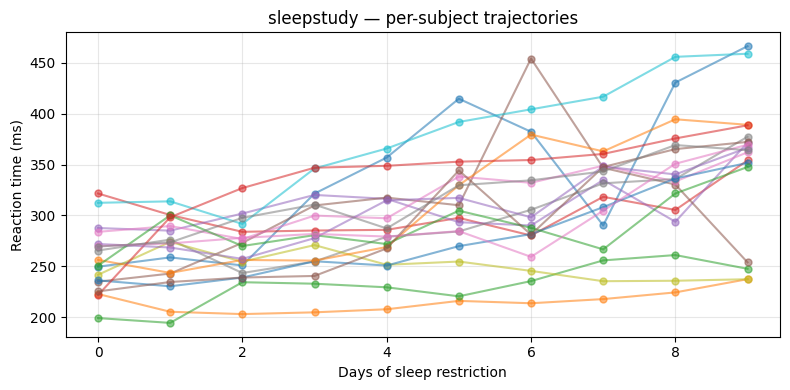

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for _, grp in df.groupby('group'):
    ax.plot(grp['Days'], grp['y'], 'o-', alpha=0.55, lw=1.5, ms=5)
ax.set_xlabel('Days of sleep restriction')
ax.set_ylabel('Reaction time (ms)')
ax.set_title('sleepstudy — per-subject trajectories')
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


## 2. Inference

Describe the model with a standard **lme4-style formula**: `Days` enters as a fixed slope
and each subject gets its own random intercept.

`mb.sample()` routes the dataset to the right submodel, runs the neural posterior
approximator, and returns 1 000 posterior draws — all in under a second.


In [4]:
result = mb.sample(
    prep,
    formula='y ~ Days + (1 | group)',
    n_samples=1000,
    diagnostics=True,
)
# Restore subject labels (lost when passing a preprocessed dict instead of the raw DataFrame).
result.group_names = sorted(str(v) for v in df['group'].unique())


## 3. Results

All estimates are on the **original scale** of the data (ms).

The summary table reports:

| Column | Meaning |
|--------|----------|
| Mean, SD, 2.5 %, 97.5 % | Posterior mean, standard deviation, and 95 % credible interval |
| P(>0) | Posterior probability that the effect is positive |
| Contr. | **Contraction** — how much the posterior tightened relative to the prior (1 = fully data-driven, 0 = prior dominated) |

Fit metrics: **R²** (variance explained), **LOO-NLL** (leave-one-out log-loss), and
**Pareto k** (LOO reliability; values below 0.7 are fine).


In [5]:
print(mb.posteriorSummary(result, x_scale='original'))


Formula:  y ~ Days + (1 | group)
Scale:    original  (slopes: Δy per unit predictor; σ and rfx: y units)
Priors:
  Intercept ~ N(298.5, 140.4)
  days ~ N(0, 48.89)
  σ_Intercept ~ HN(140.4)

Fixed Effects:
|           |    Mean |     SD |    2.5% |   97.5% |   P(>0) |   Contr. |
|:----------|--------:|-------:|--------:|--------:|--------:|---------:|
| Intercept | 250.195 | 12.445 | 225.464 | 274.163 |   1.000 |    0.992 |
| days      |  10.587 |  1.573 |   7.715 |  13.698 |   1.000 |    0.999 |

Standard Deviations (y units):
|           |   Mean |    SD |   2.5% |   97.5% |
|:----------|-------:|------:|-------:|--------:|
| Intercept | 40.336 | 8.462 | 27.345 |  59.786 |
| Residual  | 31.243 | 1.717 | 28.177 |  34.715 |

n_samples = 1000   R² = 0.726   LOO-NLL = 0.905   Pareto k = 0.219


The **random-effects table** shows how each subject's baseline reaction time deviates from
the population intercept.


In [6]:
print(mb.rfxTable(result))


Random Effects:
Scale:    original y units  (intercept deviations from population intercept β₀)
|   Group |   Intercept Mean |   Intercept 2.5% |   Intercept 97.5% |
|---------|------------------|------------------|-------------------|
|     308 |           41.706 |           14.242 |            69.605 |
|     309 |          -76.898 |         -103.683 |           -48.251 |
|     310 |          -62.946 |          -89.606 |           -35.338 |
|     330 |            4.349 |          -20.891 |            30.767 |
|     331 |           10.591 |          -13.695 |            36.695 |
|     332 |            8.837 |          -17.510 |            34.214 |
|     333 |           17.341 |           -8.493 |            42.985 |
|     334 |           -2.011 |          -30.047 |            25.603 |
|     335 |          -44.700 |          -72.750 |           -18.407 |
|     337 |           73.444 |           46.816 |           101.574 |
|     349 |          -20.360 |          -48.104 |             6.

## 4. Posterior distributions

The pair grid below shows the joint posterior over all global parameters — intercept,
Days slope, between-subject SD (σ_Intercept), and residual SD (σ_ε).

- **Diagonal** — marginal posterior (green) with the **prior** (blue) overlaid. A narrow
  posterior relative to its prior means the data were informative for that parameter.
- **Upper triangle** — posterior scatter.
- **Lower triangle** — posterior density contours.


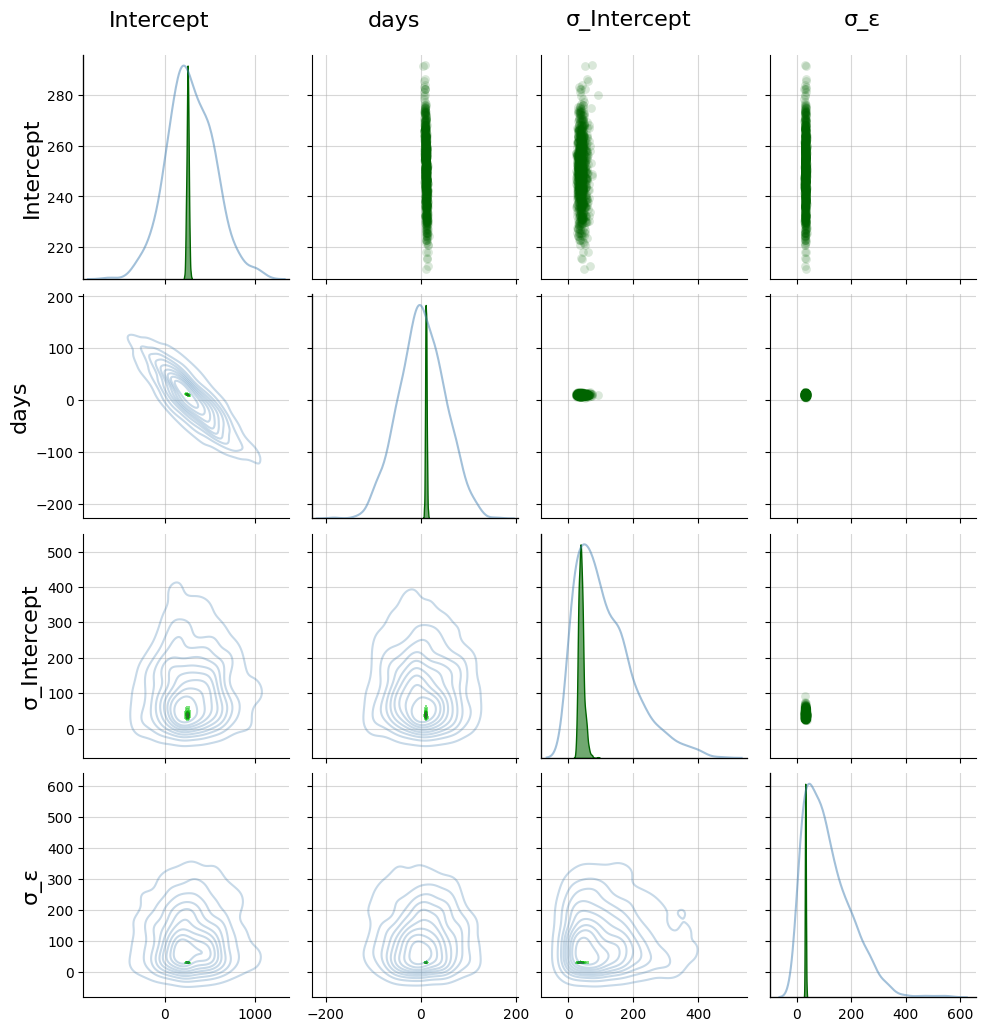

In [7]:
def _makePriorProposal(result, n_samples: int = 1000) -> Proposal:
    """Sample from the prior distributions stored in result, in original-scale units."""
    pp, si = result.prior_params, result.scale_info
    sd_y = si.y_std
    d = len(result.param_names['ffx'])
    q = len(result.param_names['sigma_rfx'])

    tau_f = torch.tensor(pp['tau_ffx'][0, :d], dtype=torch.float32) * sd_y
    nu_f  = torch.tensor(pp['nu_ffx'][0,  :d], dtype=torch.float32) * sd_y
    tau_r = torch.tensor(pp['tau_rfx'][0,  :q], dtype=torch.float32) * sd_y

    ffx  = torch.distributions.Normal(nu_f, tau_f).sample((n_samples,))
    srfx = torch.distributions.HalfNormal(tau_r).sample((n_samples,))
    seps = torch.distributions.HalfNormal(torch.tensor([2.5 * sd_y])).sample((n_samples,))

    ffx_orig  = si.to_original_scale(ffx)                                  # back-transform
    samples_g = torch.cat([ffx_orig, srfx, seps], dim=-1).unsqueeze(0)    # (1, S, d+q+1)
    return Proposal(
        proposed={
            'global': {'samples': samples_g, 'log_prob': torch.zeros(1, n_samples)},
            'local':  {'samples': torch.zeros(1, 1, n_samples, q),
                       'log_prob': torch.zeros(1, 1, n_samples)},
        },
        has_sigma_eps=True,
    )


# Build original-scale posterior proposal
ffx_orig  = result.scale_info.to_original_scale(result.proposal.ffx[0])  # (S, d)
srfx      = result.proposal.sigma_rfx[0]                                  # (S, q)
seps      = result.proposal.sigma_eps[0].unsqueeze(-1)                    # (S, 1)
samples_g = torch.cat([ffx_orig, srfx, seps], dim=-1).unsqueeze(0)
post_orig = Proposal(
    proposed={
        'global': {'samples': samples_g, 'log_prob': result.proposal.log_prob_g},
        'local':  result.proposal.data['local'],
    },
    has_sigma_eps=True,
)

param_names = result.param_names or {}
n_ffx  = len(param_names.get('ffx', []))
n_srfx = len(param_names.get('sigma_rfx', []))
names  = (
    param_names.get('ffx', [])
    + [f'σ_{n}' for n in param_names.get('sigma_rfx', [])]
    + ['σ_ε']
)

plotParameters(
    post_orig,
    prior=_makePriorProposal(result),
    names=names,
    d_active=n_ffx,
    q_active=n_srfx,
);
